In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/sample_data/student-por.csv',sep=';')

In [ ]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
print("shape",df.shape)
print("columns",list(df.columns))
print("Dtypes",df.dtypes)
print("missing_value")
print(df.isnull().sum())
print(df.head(3))

shape (649, 33)
columns ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
Dtypes school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1         

- **schoolsup:** Extra educational support from the school ($yes$ / $no$)
- **famsup:** Educational support from family ($yes$ / $no$)
- **paid:** Extra paid classes/tutoring ($yes$ / $no$)
- **activities:** Extra-curricular activities ($yes$ / $no$)
- **nursery:** Attended nursery school ($yes$ / $no$)
- **famrel:** Quality of family relationships ($1$ = *very bad* to $5$ = *excellent*)

In [ ]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
columns = list(df.columns)
# this helps making df.cols mutable

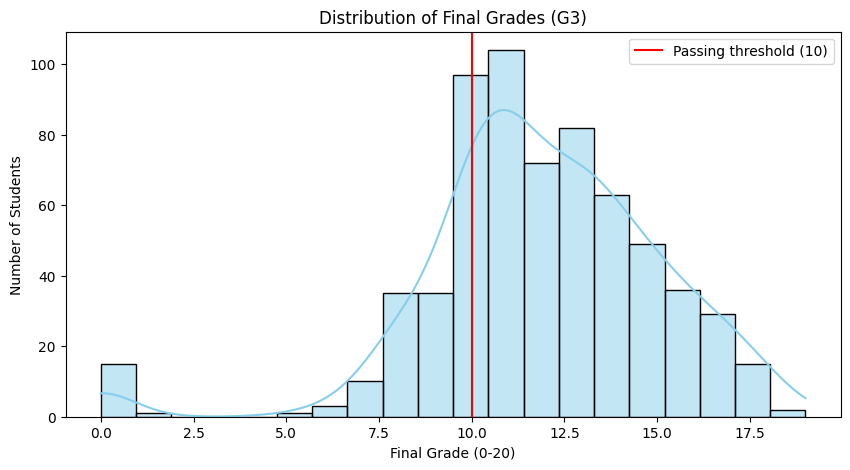

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['G3'], bins=20, kde=True, color='skyblue')
plt.axvline(x=10, color='red', label='Passing threshold (10)')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade (0-20)')
plt.ylabel('Number of Students')
plt.legend()
plt.show()


In [ ]:
(df['freetime']).dtype

dtype('int64')

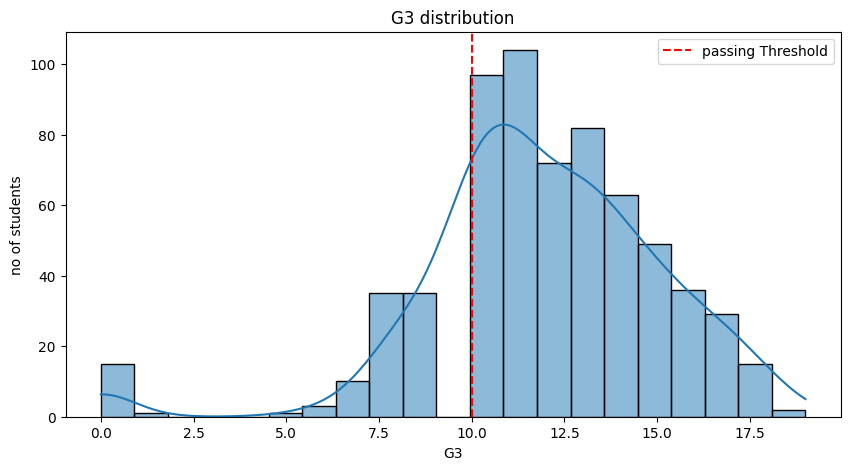

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['G3'],kde=True)
plt.axvline(x=10,linestyle='--',color='red',label = 'passing Threshold')
plt.title('G3 distribution')
plt.xlabel('G3')
plt.ylabel('no of students')
plt.legend()
plt.show()

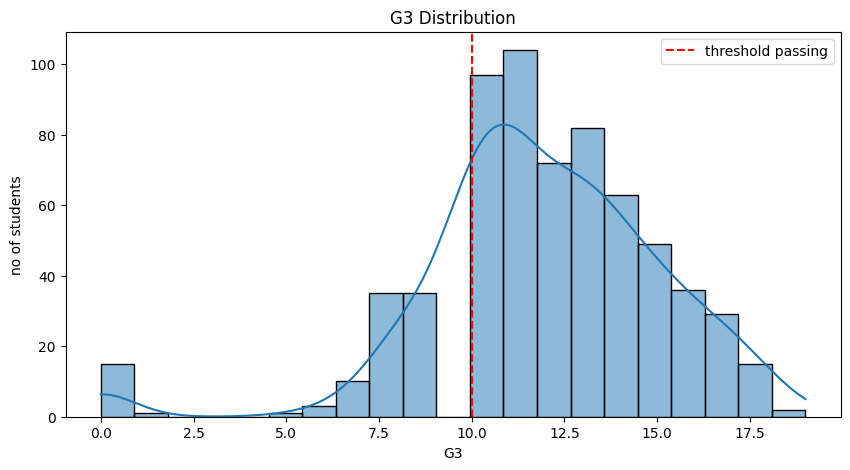

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df,x ='G3',kde=True)
plt.axvline(x=10,color = 'red',linestyle='--',label='threshold passing')
plt.title('G3 Distribution')
plt.ylabel('no of students')
plt.legend()
plt.show()

In [ ]:
df['pass'] = (df['G3']>=10).astype(int)

In [ ]:
df['pass']

,pass
0,1
1,1
2,1
3,1
4,1
...,...
644,1
645,1
646,0
647,1


In [ ]:
print(df['pass'].value_counts())
print(df['pass'].value_counts(normalize=True))

pass
1    549
0    100
Name: count, dtype: int64
pass
1    0.845917
0    0.154083
Name: proportion, dtype: float64


data is imbalence so i need to take care for this first i will proceed with base model then upon optimization /handeling imbalence if there is improvement then only i will proceed further

In [ ]:
numeric_features = ['age','Medu','Fedu','traveltime','studytime','failures','famrel','freetime','goout','Dalc','Walc','health','absences']


In [ ]:
print(df[numeric_features + ['G3']].corr()['G3'].sort_values(ascending=False))

G3            1.000000
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64


In [ ]:
df[numeric_features+['G3']].corr()['G3'].sort_values(ascending=False)

,G3
G3,1.000000
studytime,0.249789
Medu,0.240151
Fedu,0.211800
famrel,0.063361
goout,-0.087641
absences,-0.091379
health,-0.098851
age,-0.106505
freetime,-0.122705


corelation is not that strong

In [ ]:
print(df.groupby('failures')['G3'].mean())

failures
0    12.510018
1     8.642857
2     8.812500
3     8.071429
Name: G3, dtype: float64


In [ ]:
df.groupby('failures')['G3'].mean()

,G3
failures,
0,12.510018
1,8.642857
2,8.812500
3,8.071429


In [ ]:
print(df.groupby('schoolsup')['G3'].mean())
print(df.groupby('higher')['G3'].mean())

schoolsup
no     11.979346
yes    11.279412
Name: G3, dtype: float64
higher
no      8.797101
yes    12.275862
Name: G3, dtype: float64


In [ ]:
df.groupby('schoolsup')['G3'].max()

,G3
schoolsup,
no,19
yes,18


we can consider removing the schoolups column as its group by shows
```
1. max is almost same
2. mean is same
3. min is also same
```

so its hardly adding any impact

In [ ]:
print(df['absences'].describe())

count    649.000000
mean       3.659476
std        4.640759
min        0.000000
25%        0.000000
50%        2.000000
75%        6.000000
max       32.000000
Name: absences, dtype: float64


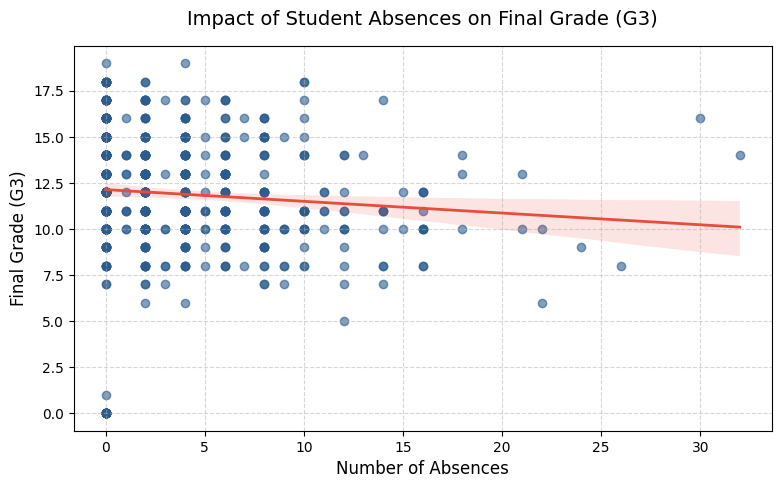

In [ ]:
plt.figure(figsize=(9, 5))
sns.regplot(data=df, x='absences', y='G3',
scatter_kws={'alpha': 0.6, 'color': '#2b5c8f'},
line_kws={'color': '#e74c3c', 'linewidth': 2})

plt.title('Impact of Student Absences on Final Grade (G3)', fontsize=14, pad=15)
plt.xlabel('Number of Absences', fontsize=12)
plt.ylabel('Final Grade (G3)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

it has the slight effect the reg line is bending so open increasing no of absence there is chance of low grade

In [ ]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0,11,11,1
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9,11,11,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12,13,12,1
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14,14,14,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11,13,13,1


In [ ]:
excluded ={
    'G1':'mid dem grades leakage',
    'G2':'late sem grades still leakage',
    'G3':'this is the terget,never a failure'
}
target_col = 'pass'
drop_cols = ['G1','G2','G3','pass']

feature_cols=[c for c in df.columns if c not in drop_cols]
print(len(feature_cols),'features')
print(feature_cols)

30 features
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [ ]:
df[feature_cols]

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,yes,yes,no,5,4,2,1,2,5,4
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,yes,yes,no,4,3,4,1,1,1,4
646,MS,F,18,U,GT3,T,1,1,other,other,...,yes,no,no,1,1,1,1,1,5,6
647,MS,M,17,U,LE3,T,3,1,services,services,...,yes,yes,no,2,4,5,3,4,2,6


In [ ]:
binary_col=[]

In [ ]:
for i in feature_cols:
  if df[i].dtype=='object' and df[i].nunique()==2 :
    binary_col.append(i)


In [ ]:
print("binary_cols")
binary_col

binary_cols


['school',
 'sex',
 'address',
 'famsize',
 'Pstatus',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic']

what is the diff between attribute and function

In [ ]:
ohe_cols =[]
for i in feature_cols:
  if df[i].dtype=='object' and df[i].nunique() >2 :
    ohe_cols.append(i)

In [ ]:
print("ohe_cols")
ohe_cols

ohe_cols


['Mjob', 'Fjob', 'reason', 'guardian']

In [ ]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder

In [ ]:
ohe = OneHotEncoder(drop='first',sparse_output=False).set_output(transform ='pandas')
ohe_binary = OneHotEncoder(drop='first',sparse_output=False).set_output(transform ='pandas')

In [ ]:
ohe.fit(df[ohe_cols])

OneHotEncoder(drop='first', sparse_output=False)

In [ ]:
transformed_ohe_data=ohe.transform(df[ohe_cols])

In [ ]:
df.drop(columns=ohe_cols,inplace=True)

In [ ]:
df= pd.concat([df,transformed_ohe_data],axis=1)

In [ ]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,GP,F,18,U,GT3,A,4,4,2,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,GP,F,17,U,GT3,T,1,1,1,2,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,GP,F,15,U,LE3,T,1,1,1,2,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,GP,F,15,U,GT3,T,4,2,1,3,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4,GP,F,16,U,GT3,T,3,3,1,2,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,1,3,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
645,MS,F,18,U,LE3,T,3,1,1,2,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
646,MS,F,18,U,GT3,T,1,1,2,2,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
647,MS,M,17,U,LE3,T,3,1,2,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
df[binary_col] = ohe_binary.fit_transform(df[binary_col])

In [ ]:
df[binary_col]

,school,sex,address,famsize,Pstatus,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
3,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
645,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
646,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
647,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [ ]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0.0,0.0,18,1.0,0.0,0.0,4,4,2,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,17,1.0,0.0,1.0,1,1,1,2,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,15,1.0,1.0,1.0,1,1,1,2,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,0.0,15,1.0,0.0,1.0,4,2,1,3,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.0,0.0,16,1.0,0.0,1.0,3,3,1,2,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,1.0,0.0,19,0.0,0.0,1.0,2,3,1,3,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
645,1.0,0.0,18,1.0,1.0,1.0,3,1,1,2,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
646,1.0,0.0,18,1.0,0.0,1.0,1,1,2,2,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
647,1.0,1.0,17,1.0,1.0,1.0,3,1,2,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
df[binary_col]

,school,sex,address,famsize,Pstatus,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
3,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
645,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
646,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
647,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [ ]:
feature_cols = [c for c in df.columns if c not in ['G1', 'G2', 'G3', 'pass']]
print(len(feature_cols))
print(feature_cols)

39
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other']


<Axes: xlabel='age', ylabel='Count'>

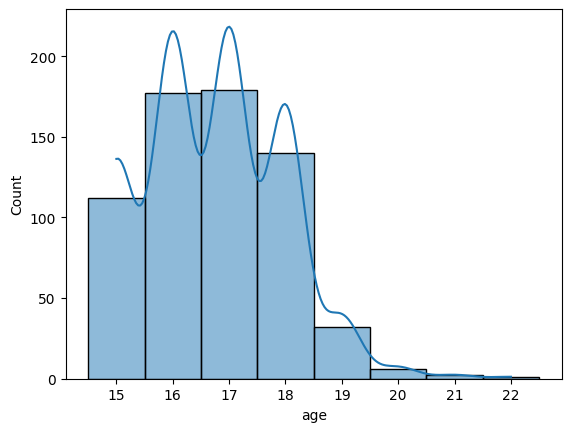

In [ ]:
sns.histplot(df,x='age',discrete=True,kde=True)

here the data is first right skwed and its scale is more compared to other numerical cols so in future if i choose to use linear model then its worth doing transformation like(log,scaling as well) or yeo-johnson can also be used

In [ ]:
from sklearn.model_selection import train_test_split
x = df[feature_cols]
y = df['pass']

In [ ]:
x_train,x_test ,y_train,y_test =train_test_split(
x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
print(y_test.mean())

0.8461538461538461


In [ ]:
print(y_train.mean())

0.8458574181117534


In [ ]:
x_test.shape

(130, 39)

In [ ]:
x_train.shape

(519, 39)

Setting up base model for ref

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

In [ ]:
from numpy import random
model = XGBClassifier(
    random_state = 42,eval_metric='logloss'
)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(f"accuracy score ={accuracy_score(y_test,y_pred)}")
print(f"precision score ={precision_score(y_test,y_pred)}")
print(f"recall score ={recall_score(y_test,y_pred)}")
print(f"F1 score ={f1_score(y_test,y_pred)}")
print()
print(f"confustion_metrics")
print(confusion_matrix(y_test,y_pred))
print(f"accuracy score ={accuracy_score(y_test,y_pred)}")
print()
print(classification_report(y_test,y_pred))

accuracy score =0.7846153846153846
precision score =0.8596491228070176
recall score =0.8909090909090909
F1 score =0.875

confustion_metrics
[[ 4 16]
 [12 98]]
accuracy score =0.7846153846153846

              precision    recall  f1-score   support

           0       0.25      0.20      0.22        20
           1       0.86      0.89      0.88       110

    accuracy                           0.78       130
   macro avg       0.55      0.55      0.55       130
weighted avg       0.77      0.78      0.77       130



In [ ]:
y_test[y_test==0].count()

np.int64(20)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
}

for name, m in models.items():
    m.fit(x_train, y_train)
    y_pred = m.predict(x_test)
    print(f'--- {name} ---')
    print(classification_report(y_test, y_pred))
    print()

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.31      0.25      0.28        20
           1       0.87      0.90      0.88       110

    accuracy                           0.80       130
   macro avg       0.59      0.57      0.58       130
weighted avg       0.78      0.80      0.79       130


--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.19      0.15      0.17        20
           1       0.85      0.88      0.87       110

    accuracy                           0.77       130
   macro avg       0.52      0.52      0.52       130
weighted avg       0.75      0.77      0.76       130


--- Random Forest ---
              precision    recall  f1-score   support

           0       0.27      0.15      0.19        20
           1       0.86      0.93      0.89       110

    accuracy                           0.81       130
   macro avg       0.56      0.54      0.54       130


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

rus = RandomUnderSampler(random_state=42)
x_train_under, y_train_under = rus.fit_resample(x_train, y_train)

print('Before:', y_train.value_counts().to_dict())
print('After undersampling:', y_train_under.value_counts().to_dict())

model_under = LogisticRegression(max_iter=1000, random_state=42)
model_under.fit(x_train_under, y_train_under)
y_pred_under = model_under.predict(x_test)

print(classification_report(y_test, y_pred_under))

Before: {1: 439, 0: 80}
After undersampling: {0: 80, 1: 80}
              precision    recall  f1-score   support

           0       0.22      0.55      0.32        20
           1       0.89      0.65      0.75       110

    accuracy                           0.64       130
   macro avg       0.56      0.60      0.54       130
weighted avg       0.79      0.64      0.69       130



In [ ]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

ros = RandomOverSampler(random_state=42)
x_train_over, y_train_over = ros.fit_resample(x_train, y_train)

print('Before:', y_train.value_counts().to_dict())
print('After oversampling:', y_train_over.value_counts().to_dict())

model_over = LogisticRegression(max_iter=1000, random_state=42)
model_over.fit(x_train_over, y_train_over)
y_pred_over = model_over.predict(x_test)

print(classification_report(y_test, y_pred_over))

Before: {1: 439, 0: 80}
After oversampling: {1: 439, 0: 439}
              precision    recall  f1-score   support

           0       0.22      0.50      0.30        20
           1       0.88      0.67      0.76       110

    accuracy                           0.65       130
   macro avg       0.55      0.59      0.53       130
weighted avg       0.78      0.65      0.69       130



In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print('Before:', y_train.value_counts().to_dict())
print('After SMOTE:', y_train_smote.value_counts().to_dict())

model_smote = LogisticRegression(max_iter=1000, random_state=42)
model_smote.fit(x_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(x_test)

print(classification_report(y_test, y_pred_smote))

Before: {1: 439, 0: 80}
After SMOTE: {1: 439, 0: 439}
              precision    recall  f1-score   support

           0       0.21      0.35      0.26        20
           1       0.86      0.75      0.81       110

    accuracy                           0.69       130
   macro avg       0.54      0.55      0.53       130
weighted avg       0.76      0.69      0.72       130



In [ ]:
from imblearn.over_sampling import SMOTENC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# columns we consider truly continuous/ordinal numeric
continuous_cols = ['age','Medu','Fedu','traveltime','studytime','failures',
                    'famrel','freetime','goout','Dalc','Walc','health','absences']

# everything else in feature_cols is categorical (binary + one-hot columns)
categorical_cols = [c for c in feature_cols if c not in continuous_cols]

# SMOTENC needs the *positions* (indices), not names
categorical_indices = [x_train.columns.get_loc(c) for c in categorical_cols]

print('Num categorical columns:', len(categorical_indices))

smotenc = SMOTENC(categorical_features=categorical_indices, random_state=42)
x_train_smotenc, y_train_smotenc = smotenc.fit_resample(x_train, y_train)

print('Before:', y_train.value_counts().to_dict())
print('After SMOTENC:', y_train_smotenc.value_counts().to_dict())

model_smotenc = LogisticRegression(max_iter=1000, random_state=42)
model_smotenc.fit(x_train_smotenc, y_train_smotenc)
y_pred_smotenc = model_smotenc.predict(x_test)

print(classification_report(y_test, y_pred_smotenc))

Num categorical columns: 26
Before: {1: 439, 0: 80}
After SMOTENC: {1: 439, 0: 439}
              precision    recall  f1-score   support

           0       0.22      0.25      0.23        20
           1       0.86      0.84      0.85       110

    accuracy                           0.75       130
   macro avg       0.54      0.54      0.54       130
weighted avg       0.76      0.75      0.75       130



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

datasets = {
    'Undersampling': (x_train_under, y_train_under),
    'Oversampling': (x_train_over, y_train_over),
    'SMOTE': (x_train_smote, y_train_smote),
    'SMOTENC': (x_train_smotenc, y_train_smotenc),
}

models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
}

for data_name, (xt, yt) in datasets.items():
    for model_name, model in models.items():
        model.fit(xt, yt)
        y_pred = model.predict(x_test)
        report = classification_report(y_test, y_pred, output_dict=True)
        print(f"{data_name} + {model_name}: "
              f"Fail Precision={report['0']['precision']:.2f}, "
              f"Fail Recall={report['0']['recall']:.2f}, "
              f"Fail F1={report['0']['f1-score']:.2f}")

Undersampling + Random Forest: Fail Precision=0.24, Fail Recall=0.60, Fail F1=0.35
Undersampling + XGBoost: Fail Precision=0.24, Fail Recall=0.50, Fail F1=0.33
Oversampling + Random Forest: Fail Precision=0.24, Fail Recall=0.20, Fail F1=0.22
Oversampling + XGBoost: Fail Precision=0.20, Fail Recall=0.20, Fail F1=0.20
SMOTE + Random Forest: Fail Precision=0.19, Fail Recall=0.15, Fail F1=0.17
SMOTE + XGBoost: Fail Precision=0.19, Fail Recall=0.20, Fail F1=0.20
SMOTENC + Random Forest: Fail Precision=0.25, Fail Recall=0.20, Fail F1=0.22
SMOTENC + XGBoost: Fail Precision=0.17, Fail Recall=0.15, Fail F1=0.16


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

fail_count = (y_train == 0).sum()
pass_count = (y_train == 1).sum()
spw = fail_count / pass_count

print('Fail count:', fail_count, '| Pass count:', pass_count)
print('scale_pos_weight:', spw)

model_spw = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=spw)
model_spw.fit(x_train, y_train)   # note: ORIGINAL x_train/y_train, no resampling
y_pred_spw = model_spw.predict(x_test)

print(classification_report(y_test, y_pred_spw))

Fail count: 80 | Pass count: 439
scale_pos_weight: 0.18223234624145787
              precision    recall  f1-score   support

           0       0.20      0.20      0.20        20
           1       0.85      0.85      0.85       110

    accuracy                           0.75       130
   macro avg       0.53      0.53      0.53       130
weighted avg       0.75      0.75      0.75       130



In [ ]:
from sklearn.metrics import classification_report
import numpy as np

model_best = RandomForestClassifier(random_state=42)
model_best.fit(x_train_under, y_train_under)

# predict_proba returns [P(class 0), P(class 1)] for each row
y_proba_fail = model_best.predict_proba(x_test)[:, 0]  # just P(fail) column

for threshold in [0.5, 0.4, 0.3, 0.25, 0.2]:
    # if P(fail) >= threshold, predict fail(0), else predict pass(1)
    y_pred_thresh = np.where(y_proba_fail >= threshold, 0, 1)
    print(f'--- Threshold = {threshold} ---')
    print(classification_report(y_test, y_pred_thresh))
    print()

--- Threshold = 0.5 ---
              precision    recall  f1-score   support

           0       0.24      0.60      0.35        20
           1       0.90      0.66      0.76       110

    accuracy                           0.65       130
   macro avg       0.57      0.63      0.56       130
weighted avg       0.80      0.65      0.70       130


--- Threshold = 0.4 ---
              precision    recall  f1-score   support

           0       0.20      0.60      0.30        20
           1       0.89      0.56      0.69       110

    accuracy                           0.57       130
   macro avg       0.54      0.58      0.49       130
weighted avg       0.78      0.57      0.63       130


--- Threshold = 0.3 ---
              precision    recall  f1-score   support

           0       0.18      0.70      0.28        20
           1       0.88      0.41      0.56       110

    accuracy                           0.45       130
   macro avg       0.53      0.55      0.42       130


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# model + which training data it uses
configs = {
    'LogReg + Undersampling': (LogisticRegression(max_iter=1000, random_state=42), x_train_under, y_train_under),
    'RandomForest + Undersampling': (RandomForestClassifier(random_state=42), x_train_under, y_train_under),
    'XGBoost + Undersampling': (XGBClassifier(random_state=42, eval_metric='logloss'), x_train_under, y_train_under),
    'XGBoost + scale_pos_weight': (XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=spw), x_train, y_train),
}

thresholds = [0.5, 0.4, 0.3, 0.25, 0.2]

results = []
for config_name, (model, xt, yt) in configs.items():
    model.fit(xt, yt)
    y_proba_fail = model.predict_proba(x_test)[:, 0]
    for t in thresholds:
        y_pred_t = np.where(y_proba_fail >= t, 0, 1)
        p = precision_score(y_test, y_pred_t, pos_label=0)
        r = recall_score(y_test, y_pred_t, pos_label=0)
        f = f1_score(y_test, y_pred_t, pos_label=0)
        results.append((config_name, t, round(p,2), round(r,2), round(f,2)))

for row in results:
    print(row)

('LogReg + Undersampling', 0.5, 0.22, 0.55, 0.32)
('LogReg + Undersampling', 0.4, 0.22, 0.6, 0.32)
('LogReg + Undersampling', 0.3, 0.19, 0.6, 0.29)
('LogReg + Undersampling', 0.25, 0.2, 0.65, 0.31)
('LogReg + Undersampling', 0.2, 0.18, 0.65, 0.28)
('RandomForest + Undersampling', 0.5, 0.24, 0.6, 0.35)
('RandomForest + Undersampling', 0.4, 0.2, 0.6, 0.3)
('RandomForest + Undersampling', 0.3, 0.18, 0.7, 0.28)
('RandomForest + Undersampling', 0.25, 0.18, 0.8, 0.29)
('RandomForest + Undersampling', 0.2, 0.17, 0.85, 0.28)
('XGBoost + Undersampling', 0.5, 0.24, 0.5, 0.33)
('XGBoost + Undersampling', 0.4, 0.2, 0.5, 0.29)
('XGBoost + Undersampling', 0.3, 0.19, 0.5, 0.27)
('XGBoost + Undersampling', 0.25, 0.18, 0.5, 0.26)
('XGBoost + Undersampling', 0.2, 0.2, 0.6, 0.3)
('XGBoost + scale_pos_weight', 0.5, 0.2, 0.2, 0.2)
('XGBoost + scale_pos_weight', 0.4, 0.26, 0.3, 0.28)
('XGBoost + scale_pos_weight', 0.3, 0.21, 0.3, 0.24)
('XGBoost + scale_pos_weight', 0.25, 0.18, 0.3, 0.23)
('XGBoost + scale_

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 29.5 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 2, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42
    )
    model.fit(x_train_under, y_train_under)
    y_pred = model.predict(x_test)
    return f1_score(y_test, y_pred, pos_label=0)  # F1 for the fail class

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print('Best F1:', study.best_value)
print('Best params:', study.best_params)

[I 2026-08-02 06:03:15,461] A new study created in memory with name: no-name-7c406354-2461-4175-8692-6001aadfebf3
[I 2026-08-02 06:03:15,809] Trial 0 finished with value: 0.2903225806451613 and parameters: {'n_estimators': 130, 'max_depth': 16, 'min_samples_split': 18, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.2903225806451613.
[I 2026-08-02 06:03:16,698] Trial 1 finished with value: 0.3225806451612903 and parameters: {'n_estimators': 280, 'max_depth': 20, 'min_samples_split': 19, 'min_samples_leaf': 7, 'max_features': None}. Best is trial 1 with value: 0.3225806451612903.
[I 2026-08-02 06:03:17,214] Trial 2 finished with value: 0.3103448275862069 and parameters: {'n_estimators': 185, 'max_depth': 18, 'min_samples_split': 14, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 1 with value: 0.3225806451612903.
[I 2026-08-02 06:03:17,411] Trial 3 finished with value: 0.30303030303030304 and parameters: {'n_estimators': 70, 'max_depth': 8, 'm

Best F1: 0.3728813559322034
Best params: {'n_estimators': 204, 'max_depth': 6, 'min_samples_split': 14, 'min_samples_leaf': 4, 'max_features': None}


In [ ]:
model1 = RandomForestClassifier(
    n_estimators=82,
    max_depth = 11,
    min_samples_split = 14,
    min_samples_leaf = 9,
    max_features=None,
    random_state=42
)
model1.fit(x_train,y_train)
y_predtemp = model1.predict(x_test)
print(classification_report(y_test,y_predtemp))

              precision    recall  f1-score   support

           0       0.36      0.25      0.29        20
           1       0.87      0.92      0.89       110

    accuracy                           0.82       130
   macro avg       0.61      0.58      0.59       130
weighted avg       0.79      0.82      0.80       130



In [ ]:
model1 = RandomForestClassifier(
    n_estimators=82,
    max_depth=11,
    min_samples_split=14,
    min_samples_leaf=9,
    max_features=None,
    random_state=42
)
model1.fit(x_train_under, y_train_under)
y_predtemp = model1.predict(x_test)
print(classification_report(y_test, y_predtemp))

              precision    recall  f1-score   support

           0       0.28      0.55      0.37        20
           1       0.90      0.75      0.82       110

    accuracy                           0.72       130
   macro avg       0.59      0.65      0.59       130
weighted avg       0.81      0.72      0.75       130



In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Scale first — fit the scaler ONLY on training data, then apply to both
scaler = StandardScaler()
x_train_under_scaled = scaler.fit_transform(x_train_under)
x_test_scaled = scaler.transform(x_test)

svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm_model.fit(x_train_under_scaled, y_train_under)
y_pred_svm = svm_model.predict(x_test_scaled)

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.26      0.55      0.35        20
           1       0.90      0.71      0.79       110

    accuracy                           0.68       130
   macro avg       0.58      0.63      0.57       130
weighted avg       0.80      0.68      0.72       130



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, f1_score

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear', 'poly'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced'],
}

fail_f1_scorer = make_scorer(f1_score, pos_label=0)

grid_search = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid,
    scoring=fail_f1_scorer,
    cv=5,
    n_jobs=-1
)

grid_search.fit(x_train_under_scaled, y_train_under)

print('Best F1 (cross-validated):', grid_search.best_score_)
print('Best params:', grid_search.best_params_)

best_svm = grid_search.best_estimator_
y_pred_best_svm = best_svm.predict(x_test_scaled)
print(classification_report(y_test, y_pred_best_svm))

Best F1 (cross-validated): 0.7933830334641694
Best params: {'C': 1, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.26      0.55      0.35        20
           1       0.90      0.71      0.79       110

    accuracy                           0.68       130
   macro avg       0.58      0.63      0.57       130
weighted avg       0.80      0.68      0.72       130



In [ ]:
df['total_alcohol'] = df['Dalc'] + df['Walc']
df['parent_edu_avg'] = (df['Medu'] + df['Fedu']) / 2
df['support_count'] = df['schoolsup'] + df['famsup'] + df['paid']
df['social_time'] = df['freetime'] + df['goout']
df['failures_x_absences'] = df['failures'] * df['absences']

print(df[['total_alcohol','parent_edu_avg','support_count','social_time','failures_x_absences']].head())

   total_alcohol  parent_edu_avg  support_count  social_time  \
0              2             4.0            1.0            7   
1              2             1.0            1.0            6   
2              5             1.0            1.0            5   
3              2             3.0            1.0            4   
4              3             3.0            1.0            5   

   failures_x_absences  
0                    0  
1                    0  
2                    0  
3                    0  
4                    0  


In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Rebuild feature_cols fresh from current df state (now includes the 5 new columns)
feature_cols = [c for c in df.columns if c not in ['G1', 'G2', 'G3', 'pass']]
print('Total features now:', len(feature_cols))

x = df[feature_cols]
y = df['pass']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

rus = RandomUnderSampler(random_state=42)
x_train_under, y_train_under = rus.fit_resample(x_train, y_train)

# Use our Optuna-tuned RF params from before
model_fe = RandomForestClassifier(
    n_estimators=82, max_depth=11, min_samples_split=14,
    min_samples_leaf=9, max_features=None, random_state=42
)
model_fe.fit(x_train_under, y_train_under)
y_pred_fe = model_fe.predict(x_test)

print(classification_report(y_test, y_pred_fe))

Total features now: 44
              precision    recall  f1-score   support

           0       0.26      0.50      0.34        20
           1       0.89      0.74      0.81       110

    accuracy                           0.70       130
   macro avg       0.57      0.62      0.57       130
weighted avg       0.79      0.70      0.73       130



In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

original_features = [c for c in df.columns if c not in
                      ['G1','G2','G3','pass','total_alcohol','parent_edu_avg',
                       'support_count','social_time','failures_x_absences']]

new_features = ['total_alcohol','parent_edu_avg','support_count','social_time','failures_x_absences']

results = []
for feat in new_features:
    cols = original_features + [feat]
    x = df[cols]
    y = df['pass']

    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
    )
    rus = RandomUnderSampler(random_state=42)
    x_train_under, y_train_under = rus.fit_resample(x_train, y_train)

    model = RandomForestClassifier(
        n_estimators=82, max_depth=11, min_samples_split=14,
        min_samples_leaf=9, max_features=None, random_state=42
    )
    model.fit(x_train_under, y_train_under)
    y_pred = model.predict(x_test)

    p = precision_score(y_test, y_pred, pos_label=0)
    r = recall_score(y_test, y_pred, pos_label=0)
    f = f1_score(y_test, y_pred, pos_label=0)
    results.append((feat, round(p,2), round(r,2), round(f,2)))

print('Baseline (no new features): precision=0.24, recall=0.60, f1=0.37')
print()
for row in results:
    print(row)

Baseline (no new features): precision=0.24, recall=0.60, f1=0.37

('total_alcohol', 0.28, 0.55, 0.37)
('parent_edu_avg', 0.28, 0.55, 0.37)
('support_count', 0.28, 0.55, 0.37)
('social_time', 0.28, 0.55, 0.37)
('failures_x_absences', 0.28, 0.55, 0.37)


In [ ]:
x_train_under.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid',
       'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences',
       'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher',
       'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher',
       'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother',
       'guardian_other', 'failures_x_absences'],
      dtype='object')

In [ ]:
df.shape

(649, 48)

In [ ]:
# Drop the 5 engineered columns from df entirely — reverting cleanly
df = df.drop(columns=['total_alcohol','parent_edu_avg','support_count','social_time','failures_x_absences'])

feature_cols = [c for c in df.columns if c not in ['G1','G2','G3','pass']]
print('Final feature count:', len(feature_cols))  # should be back to 39...

x = df[feature_cols]
y = df['pass']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
rus = RandomUnderSampler(random_state=42)
x_train_under, y_train_under = rus.fit_resample(x_train, y_train)

print('x_train_under shape:', x_train_under.shape)

Final feature count: 39
x_train_under shape: (160, 39)


In [ ]:
    model = RandomForestClassifier(
        n_estimators=82, max_depth=11, min_samples_split=14,
        min_samples_leaf=9, max_features=None, random_state=42
    )
    model.fit(x_train_under, y_train_under)
    y_pred = model.predict(x_test)

    p = precision_score(y_test, y_pred, pos_label=0)
    r = recall_score(y_test, y_pred, pos_label=0)
    f = f1_score(y_test, y_pred, pos_label=0)
    print(p)
    print(r)
    print(f)

0.28205128205128205
0.55
0.3728813559322034


In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report

brf = BalancedRandomForestClassifier(
    n_estimators=82, max_depth=11, min_samples_split=14,
    min_samples_leaf=9, random_state=42
)
brf.fit(x_train, y_train)   # note: ORIGINAL x_train, y_train — no manual undersampling needed
y_pred_brf = brf.predict(x_test)

print(classification_report(y_test, y_pred_brf))

              precision    recall  f1-score   support

           0       0.24      0.45      0.31        20
           1       0.88      0.74      0.80       110

    accuracy                           0.69       130
   macro avg       0.56      0.59      0.56       130
weighted avg       0.78      0.69      0.73       130



In [ ]:
from imblearn.ensemble import EasyEnsembleClassifier

eec = EasyEnsembleClassifier(n_estimators=10, random_state=42)
eec.fit(x_train, y_train)
y_pred_eec = eec.predict(x_test)
print(classification_report(y_test, y_pred_eec))

              precision    recall  f1-score   support

           0       0.26      0.60      0.36        20
           1       0.90      0.69      0.78       110

    accuracy                           0.68       130
   macro avg       0.58      0.65      0.57       130
weighted avg       0.81      0.68      0.72       130



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.metrics import make_scorer, f1_score, classification_report

fail_f1_scorer = make_scorer(f1_score, pos_label=0)

param_grid = {
    'n_estimators': [10, 20, 30, 50],
    'replacement': [True, False],
    'sampling_strategy': ['auto', 0.5, 0.75, 1.0],
}

grid_search_eec = GridSearchCV(
    estimator=EasyEnsembleClassifier(random_state=42),
    param_grid=param_grid,
    scoring=fail_f1_scorer,
    cv=5,
    n_jobs=-1
)

grid_search_eec.fit(x_train, y_train)   # original, unresampled — EEC balances internally

print('Best CV F1:', grid_search_eec.best_score_)
print('Best params:', grid_search_eec.best_params_)

best_eec = grid_search_eec.best_estimator_
y_pred_best_eec = best_eec.predict(x_test)
print(classification_report(y_test, y_pred_best_eec))

Best CV F1: 0.5500436782609958
Best params: {'n_estimators': 10, 'replacement': True, 'sampling_strategy': 0.5}
              precision    recall  f1-score   support

           0       0.28      0.40      0.33        20
           1       0.88      0.81      0.84       110

    accuracy                           0.75       130
   macro avg       0.58      0.60      0.59       130
weighted avg       0.79      0.75      0.76       130



In [ ]:
from imblearn.combine import SMOTEENN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

smoteenn = SMOTEENN(random_state=42)
x_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(x_train, y_train)

print('Before:', y_train.value_counts().to_dict())
print('After SMOTEENN:', y_train_smoteenn.value_counts().to_dict())

model_smoteenn = RandomForestClassifier(
    n_estimators=82, max_depth=11, min_samples_split=14,
    min_samples_leaf=9, max_features=None, random_state=42
)
model_smoteenn.fit(x_train_smoteenn, y_train_smoteenn)
y_pred_smoteenn = model_smoteenn.predict(x_test)
print(classification_report(y_test, y_pred_smoteenn))

Before: {1: 439, 0: 80}
After SMOTEENN: {0: 430, 1: 232}
              precision    recall  f1-score   support

           0       0.20      0.50      0.28        20
           1       0.87      0.63      0.73       110

    accuracy                           0.61       130
   macro avg       0.53      0.56      0.51       130
weighted avg       0.77      0.61      0.66       130



In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from imblearn.ensemble import EasyEnsembleClassifier

base_models = [
    ('rf', RandomForestClassifier(n_estimators=82, max_depth=11, min_samples_split=14, min_samples_leaf=9, max_features=None, random_state=42)),
    ('svm', SVC(probability=True, random_state=42)),
    ('eec', EasyEnsembleClassifier(n_estimators=10, random_state=42)),
]

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5
)

stack_model.fit(x_train_under, y_train_under)   # SVM needs scaled data ideally — see note below
y_pred_stack = stack_model.predict(x_test)
print(classification_report(y_test, y_pred_stack))

              precision    recall  f1-score   support

           0       0.24      0.45      0.32        20
           1       0.88      0.75      0.81       110

    accuracy                           0.70       130
   macro avg       0.56      0.60      0.56       130
weighted avg       0.78      0.70      0.73       130



In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer, f1_score, classification_report

fail_f1_scorer = make_scorer(f1_score, pos_label=0)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'min_child_weight': [1, 5, 10],
}

grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    scoring=fail_f1_scorer,
    cv=5,
    n_jobs=-1
)

grid_search_xgb.fit(x_train_under, y_train_under)

print('Best CV F1:', grid_search_xgb.best_score_)
print('Best params:', grid_search_xgb.best_params_)

best_xgb = grid_search_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(x_test)
print(classification_report(y_test, y_pred_best_xgb))

Best CV F1: 0.858191018342821
Best params: {'learning_rate': 0.2, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.25      0.50      0.33        20
           1       0.89      0.73      0.80       110

    accuracy                           0.69       130
   macro avg       0.57      0.61      0.57       130
weighted avg       0.79      0.69      0.73       130



In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer, f1_score, classification_report

fail_f1_scorer = make_scorer(f1_score, pos_label=0)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'min_child_weight': [1, 5, 10],
}

for k in [2,3, 5, 10]:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    grid_search = GridSearchCV(
        estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
        param_grid=param_grid,
        scoring=fail_f1_scorer,
        cv=skf,
        n_jobs=-1
    )
    grid_search.fit(x_train_under, y_train_under)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(x_test)
    test_f1 = f1_score(y_test, y_pred, pos_label=0)

    print(f'--- cv={k} ---')
    print(f'Best CV F1: {grid_search.best_score_:.3f}')
    print(f'Actual test F1: {test_f1:.3f}')
    print(f'Gap: {grid_search.best_score_ - test_f1:.3f}')
    print(f'Best params: {grid_search.best_params_}')
    print()

--- cv=3 ---
Best CV F1: 0.828
Actual test F1: 0.303
Gap: 0.525
Best params: {'learning_rate': 0.2, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 100}

--- cv=5 ---
Best CV F1: 0.821
Actual test F1: 0.361
Gap: 0.460
Best params: {'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 100}

--- cv=10 ---
Best CV F1: 0.845
Actual test F1: 0.305
Gap: 0.540
Best params: {'learning_rate': 0.2, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100}



In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer, f1_score, classification_report

fail_f1_scorer = make_scorer(f1_score, pos_label=0)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'min_child_weight': [1, 5, 10],
}

for k in [2]:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    grid_search = GridSearchCV(
        estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
        param_grid=param_grid,
        scoring=fail_f1_scorer,
        cv=skf,
        n_jobs=-1
    )
    grid_search.fit(x_train_under, y_train_under)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(x_test)
    test_f1 = f1_score(y_test, y_pred, pos_label=0)

    print(f'--- cv={k} ---')
    print(f'Best CV F1: {grid_search.best_score_:.3f}')
    print(f'Actual test F1: {test_f1:.3f}')
    print(f'Gap: {grid_search.best_score_ - test_f1:.3f}')
    print(f'Best params: {grid_search.best_params_}')
    print()

--- cv=2 ---
Best CV F1: 0.794
Actual test F1: 0.295
Gap: 0.499
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 200}



In [ ]:
import shap

explainer = shap.TreeExplainer(model)  # model = your final tuned RF
shap_values = explainer.shap_values(x_test)

print(type(shap_values))
print(np.array(shap_values).shape if isinstance(shap_values, list) else shap_values.shape)

<class 'numpy.ndarray'>
(130, 39, 2)


In [ ]:
model = RandomForestClassifier(
    n_estimators=82, max_depth=11, min_samples_split=14,
    min_samples_leaf=9, max_features=None, random_state=42
)
model.fit(x_train_under, y_train_under)

RandomForestClassifier(max_depth=11, max_features=None, min_samples_leaf=9,
                       min_samples_split=14, n_estimators=82, random_state=42)

SHAP values shape (for fail class): (130, 39)
x_test shape: (130, 39)


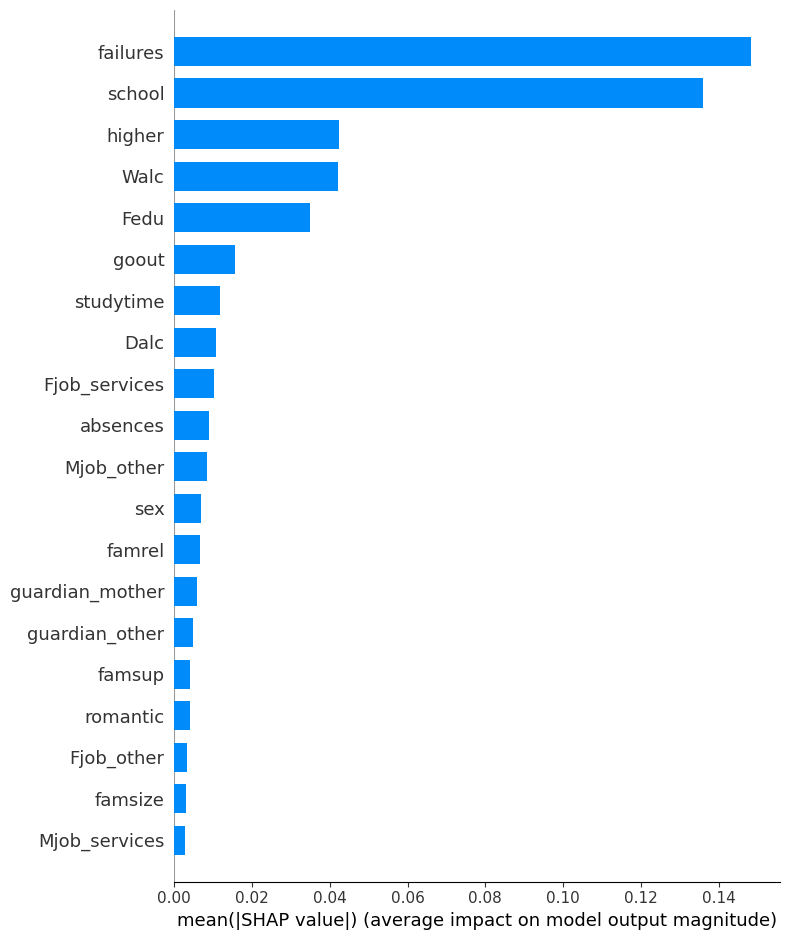

In [ ]:
import numpy as np

# Handle both possible SHAP output formats
if isinstance(shap_values, list):
    shap_values_fail = shap_values[0]   # class 0 = fail
elif shap_values.ndim == 3:
    shap_values_fail = shap_values[:, :, 0]   # class 0 = fail
else:
    shap_values_fail = shap_values

print('SHAP values shape (for fail class):', shap_values_fail.shape)
print('x_test shape:', x_test.shape)

shap.summary_plot(shap_values_fail, x_test, plot_type='bar')

In [ ]:
df.groupby('school')['pass'].mean()

,pass
school,
0.0,0.924350
1.0,0.699115


In [ ]:
print(df['school'].value_counts())
print()
print(df['school'].value_counts(normalize=True))

school
0.0    423
1.0    226
Name: count, dtype: int64

school
0.0    0.651772
1.0    0.348228
Name: proportion, dtype: float64


In [ ]:
# Get model's fail-probability for every test student
y_proba_fail = model.predict_proba(x_test)[:, 0]

# Find a student who was correctly flagged as fail (true positive) - good example case
test_indices = x_test.index
results_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted_proba_fail': y_proba_fail,
}, index=test_indices)

true_positives = results_df[(results_df['actual'] == 0) & (results_df['predicted_proba_fail'] >= 0.5)]
print('Correctly flagged at-risk students:')
print(true_positives.sort_values('predicted_proba_fail', ascending=False))

Correctly flagged at-risk students:
     actual  predicted_proba_fail
500       0              0.952380
502       0              0.912970
567       0              0.838735
624       0              0.838725
597       0              0.814981
255       0              0.736210
175       0              0.728078
570       0              0.624025
586       0              0.558990
588       0              0.520224
305       0              0.518976


Student features:
school                1.0
sex                   1.0
age                  17.0
address               1.0
famsize               0.0
Pstatus               1.0
Medu                  1.0
Fedu                  2.0
traveltime            1.0
studytime             1.0
failures              1.0
schoolsup             0.0
famsup                1.0
paid                  0.0
activities            1.0
nursery               1.0
higher                0.0
internet              1.0
romantic              1.0
famrel                5.0
freetime              3.0
goout                 5.0
Dalc                  5.0
Walc                  5.0
health                1.0
absences             12.0
Mjob_health           0.0
Mjob_other            1.0
Mjob_services         0.0
Mjob_teacher          0.0
Fjob_health           0.0
Fjob_other            1.0
Fjob_services         0.0
Fjob_teacher          0.0
reason_home           0.0
reason_other          0.0
reason_reputation     0.0
guardian_mother     

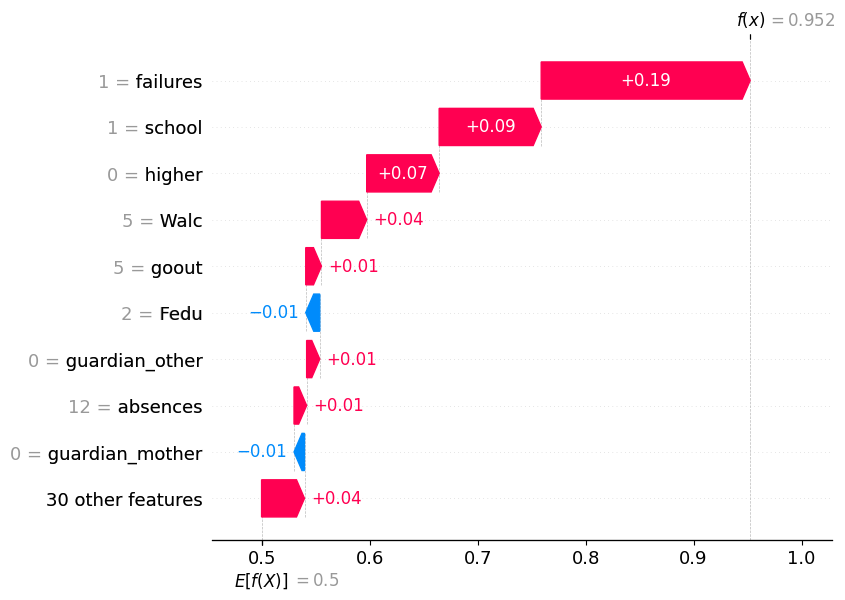

In [ ]:
student_idx = 500

# Find this student's position within x_test (SHAP values are ordered by position, not by original index)
position = list(x_test.index).index(student_idx)

print('Student features:')
print(x_test.loc[student_idx])
print()
print('Predicted fail probability:', y_proba_fail[position])
print('Actual outcome:', y_test.loc[student_idx])

# Waterfall plot - shows exactly what pushed this student's risk up/down
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_fail[position],
        base_values=explainer.expected_value[0] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
        data=x_test.loc[student_idx],
        feature_names=x_test.columns.tolist()
    )
)

In [ ]:
def generate_explanation(student_idx, x_test, shap_values_fail, feature_names, top_n=3):
    position = list(x_test.index).index(student_idx)
    values = shap_values_fail[position]
    student_data = x_test.loc[student_idx]

    # pair each feature with its SHAP contribution, sort by absolute impact
    contributions = sorted(
        zip(feature_names, values, student_data.values),
        key=lambda x: abs(x[1]),
        reverse=True
    )

    top_risk_factors = [(name, val, raw) for name, val, raw in contributions if val > 0][:top_n]
    top_protective = [(name, val, raw) for name, val, raw in contributions if val < 0][:2]

    explanation = "Key risk factors: "
    explanation += ", ".join([f"{name}={raw}" for name, val, raw in top_risk_factors])
    if top_protective:
        explanation += ". Protective factors: "
        explanation += ", ".join([f"{name}={raw}" for name, val, raw in top_protective])

    return explanation

print(generate_explanation(500, x_test, shap_values_fail, x_test.columns.tolist()))

Key risk factors: failures=1.0, school=1.0, higher=0.0. Protective factors: Fedu=2.0, guardian_mother=0.0


In [ ]:
def humanize_feature(name, value):
    """Translate a raw feature name+value into a plain-English phrase."""

    templates = {
        'failures': lambda v: f"has {int(v)} prior class failure(s)" if v > 0 else "has no prior class failures",
        'school': lambda v: "attends the higher-risk school (MS)" if v == 1 else "attends Gabriel Pereira (GP)",
        'higher': lambda v: "does not plan to pursue higher education" if v == 0 else "plans to pursue higher education",
        'absences': lambda v: f"has {int(v)} absences this term" if v > 5 else f"has low absences ({int(v)})",
        'Walc': lambda v: f"reports high weekend alcohol use (level {int(v)}/5)" if v >= 4 else f"reports low weekend alcohol use (level {int(v)}/5)",
        'Dalc': lambda v: f"reports high weekday alcohol use (level {int(v)}/5)" if v >= 4 else f"reports low weekday alcohol use (level {int(v)}/5)",
        'goout': lambda v: f"goes out frequently (level {int(v)}/5)" if v >= 4 else f"has moderate/low social outings (level {int(v)}/5)",
        'studytime': lambda v: f"has low weekly study time (level {int(v)}/4)" if v <= 1 else f"has adequate study time (level {int(v)}/4)",
        'Fedu': lambda v: f"father's education level is {int(v)}/4",
        'Medu': lambda v: f"mother's education level is {int(v)}/4",
        'famsup': lambda v: "lacks family educational support" if v == 0 else "has family educational support",
        'schoolsup': lambda v: "lacks extra school support" if v == 0 else "receives extra school support",
        'romantic': lambda v: "is in a romantic relationship" if v == 1 else "is not in a romantic relationship",
    }

    if name in templates:
        return templates[name](value)
    else:
        # fallback for features we haven't written a specific template for
        return f"{name}={value}"


def generate_explanation_v2(student_idx, x_test, shap_values_fail, feature_names, top_n=3):
    position = list(x_test.index).index(student_idx)
    values = shap_values_fail[position]
    student_data = x_test.loc[student_idx]

    contributions = sorted(
        zip(feature_names, values, student_data.values),
        key=lambda x: abs(x[1]),
        reverse=True
    )

    top_risk_factors = [(name, val, raw) for name, val, raw in contributions if val > 0][:top_n]
    top_protective = [(name, val, raw) for name, val, raw in contributions if val < 0][:2]

    risk_phrases = [humanize_feature(name, raw) for name, val, raw in top_risk_factors]
    protective_phrases = [humanize_feature(name, raw) for name, val, raw in top_protective]

    explanation = "This student is flagged as at-risk primarily because they " + "; and ".join(risk_phrases) + "."
    if protective_phrases:
        explanation += " On the positive side, they " + " and ".join(protective_phrases) + "."

    return explanation

print(generate_explanation_v2(500, x_test, shap_values_fail, x_test.columns.tolist()))

This student is flagged as at-risk primarily because they has 1 prior class failure(s); and attends the higher-risk school (MS); and does not plan to pursue higher education. On the positive side, they father's education level is 2/4 and guardian_mother=0.0.


In [ ]:
def humanize_feature(name, value):
    """Translate a raw feature name+value into a grammatically consistent phrase (subject: 'they')."""

    templates = {
        'failures': lambda v: f"have {int(v)} prior class failure{'s' if v != 1 else ''}" if v > 0 else "have no prior class failures",
        'school': lambda v: "attend the higher-risk school (MS)" if v == 1 else "attend Gabriel Pereira (GP)",
        'higher': lambda v: "do not plan to pursue higher education" if v == 0 else "plan to pursue higher education",
        'absences': lambda v: f"have {int(v)} absences this term" if v > 5 else f"have low absences ({int(v)})",
        'Walc': lambda v: "report high weekend alcohol use" if v >= 4 else "report low weekend alcohol use",
        'Dalc': lambda v: "report high weekday alcohol use" if v >= 4 else "report low weekday alcohol use",
        'goout': lambda v: "go out frequently with friends" if v >= 4 else "have moderate/low social outings",
        'studytime': lambda v: "have low weekly study time" if v <= 1 else "have adequate study time",
        'Fedu': lambda v: f"have a father with moderate-to-low education (level {int(v)}/4)" if v <= 2 else f"have a father with higher education (level {int(v)}/4)",
        'Medu': lambda v: f"have a mother with moderate-to-low education (level {int(v)}/4)" if v <= 2 else f"have a mother with higher education (level {int(v)}/4)",
        'famsup': lambda v: "lack family educational support" if v == 0 else "have family educational support",
        'schoolsup': lambda v: "lack extra school support" if v == 0 else "receive extra school support",
        'romantic': lambda v: "are in a romantic relationship" if v == 1 else "are not in a romantic relationship",
        'guardian_mother': lambda v: "do not have their mother as primary guardian" if v == 0 else "have their mother as primary guardian",
        'guardian_other': lambda v: None,
    }

    if name in templates:
        return templates[name](value)
    return None


def generate_explanation_v3(student_idx, x_test, shap_values_fail, feature_names, top_n=3):
    position = list(x_test.index).index(student_idx)
    values = shap_values_fail[position]
    student_data = x_test.loc[student_idx]

    contributions = sorted(
        zip(feature_names, values, student_data.values),
        key=lambda x: abs(x[1]),
        reverse=True
    )

    risk_candidates = [(name, val, raw) for name, val, raw in contributions if val > 0]
    protective_candidates = [(name, val, raw) for name, val, raw in contributions if val < 0]

    risk_phrases = [p for p in (humanize_feature(n, r) for n, v, r in risk_candidates) if p][:top_n]
    protective_phrases = [p for p in (humanize_feature(n, r) for n, v, r in protective_candidates) if p][:2]

    explanation = "This student is flagged as at-risk primarily because they " + "; ".join(risk_phrases) + "."
    if protective_phrases:
        explanation += " On the positive side, they " + " and ".join(protective_phrases) + "."

    return explanation

print(generate_explanation_v3(490, x_test, shap_values_fail, x_test.columns.tolist()))

This student is flagged as at-risk primarily because they have 1 prior class failure; attend the higher-risk school (MS); do not plan to pursue higher education. On the positive side, they report low weekend alcohol use and report low weekday alcohol use.


In [ ]:
generate_explanation_v3(500, x_test, shap_values_fail, x_test.columns.tolist())

'This student is flagged as at-risk primarily because they have 1 prior class failure; attend the higher-risk school (MS); do not plan to pursue higher education. On the positive side, they have a father with moderate-to-low education (level 2/4) and do not have their mother as primary guardian.'